**Dataset:** Daily weather observations - Raleigh-Durham International Airport  
**Source:** NOAA, 2022–2026  
**Cleaned Data:** 1,477 clean rows

| Variable | Description | Unit | Role |
|----------|-------------|------|------|
| X1 | TMAX — Max daily temperature | °F | Input |
| X2 | TMIN — Min daily temperature | °F | Input |
| X3 | PRCP — Daily precipitation | inches | Input |
| X4 | AWND — Avg wind speed | mph | Input |
| X5 | SNOW — Daily snowfall | inches | Input |
| Y  | TAVG — Avg daily temperature | °F | **Output** |

# Task 5: Model Comparison on Test Set
**Dataset:** TAVG daily temperature - Raleigh-Durham Airport, NOAA 2022–2026

All three models are re-derived from the training set in this notebook (self-contained).  
They are then evaluated on the test set using the same rolling one-step-ahead forecasting setup for a fair comparison.


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from statsmodels.tsa.stattools import pacf
from statsmodels.tsa.ar_model import AutoReg

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False
})

# Load data
df = pd.read_csv('weather_clean.csv')
y = df['Y'].values.astype(float)
n = len(y)

dates = pd.date_range(start='2022-01-01', periods=n, freq='D')
ts = pd.Series(y, index=dates, name='TAVG (°F)')

train_n = int(n * 0.8)
ts_train = ts.iloc[:train_n]
ts_test = ts.iloc[train_n:]

train_vals = ts_train.values
test_vals = ts_test.values

print(f'Total: {n} | Train: {len(ts_train)} | Test: {len(ts_test)}')

# Helper functions
def rmse(actual, predicted):
    actual = np.array(actual, dtype=float)
    predicted = np.array(predicted, dtype=float)
    return np.sqrt(np.mean((actual - predicted) ** 2))

def mape(actual, predicted):
    actual = np.array(actual, dtype=float)
    predicted = np.array(predicted, dtype=float)
    mask = actual != 0
    return np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

# SMA helper
def sma_predict(series, k):
    predicted = np.full(len(series), np.nan)
    for t in range(k, len(series)):
        predicted[t] = np.mean(series[t-k:t])
    return predicted

# Exponential smoothing helper
def exp_smooth_predict(series, alpha):
    pred = np.full(len(series), np.nan)
    pred[0] = series[0]
    for t in range(1, len(series)):
        pred[t] = alpha * series[t-1] + (1 - alpha) * pred[t-1]
    return pred

Total: 1477 | Train: 1181 | Test: 296


## Re-derive all three trained models from training data

In [32]:
# ── SMA: find best k on training set ─────────────────────────────────────────
k_values = list(range(1, 31))
rmse_sma = []

for k in k_values:
    pred = sma_predict(train_vals, k)
    valid = ~np.isnan(pred)
    rmse_sma.append(rmse(train_vals[valid], pred[valid]))

best_k = k_values[np.argmin(rmse_sma)]
sma_train_rmse = min(rmse_sma)

# ── Exp Smoothing: find best alpha on training set ───────────────────────────
alphas = [round(a, 1) for a in np.arange(0.1, 1.0, 0.1)]
rmse_es = [rmse(train_vals[1:], exp_smooth_predict(train_vals, a)[1:]) for a in alphas]

best_alpha = alphas[np.argmin(rmse_es)]
best_es_rmse = min(rmse_es)

# ── AR(p): PACF order + fit on differenced training set ──────────────────────
train_diff = ts_train.diff().dropna()
pacf_vals = pacf(train_diff, nlags=min(30, len(train_diff)//2 - 1), method='ywm')
ci = 1.96 / np.sqrt(len(train_diff))
sig_lags = [l for l in range(1, min(16, len(pacf_vals))) if abs(pacf_vals[l]) > ci]
p_selected = max(sig_lags) if sig_lags else 1

# Fit AR model on differenced training data
ar_model_train = AutoReg(train_diff.values, lags=p_selected, old_names=False).fit()

# In-sample AR training RMSE on original scale
pred_diff_train = np.array(ar_model_train.fittedvalues)
actual_diff_aligned = train_diff.values[p_selected:]

min_len = min(len(pred_diff_train), len(actual_diff_aligned))
pred_diff_aligned = pred_diff_train[:min_len]
actual_diff_aligned = actual_diff_aligned[:min_len]

y_base = ts_train.values[p_selected : p_selected + min_len]
y_prev = ts_train.values[p_selected - 1 : p_selected - 1 + min_len]
y_hat_ar = y_prev + pred_diff_aligned

ar_train_rmse = rmse(y_base, y_hat_ar)

print('Models derived from training set:')
print(f'  SMA best k      = {best_k}   (Train RMSE = {sma_train_rmse:.4f}°F)')
print(f'  ES  best alpha  = {best_alpha}  (Train RMSE = {best_es_rmse:.4f}°F)')
print(f'  AR  order p     = {p_selected}  (Train RMSE = {ar_train_rmse:.4f}°F)')

Models derived from training set:
  SMA best k      = 1   (Train RMSE = 5.8021°F)
  ES  best alpha  = 0.9  (Train RMSE = 5.8673°F)
  AR  order p     = 12  (Train RMSE = 5.7198°F)


## Task 5  - Apply to Test Set (Fair Rolling One-Step-Ahead Comparison)

In [33]:
full_vals = ts.values

# SMA on test set: rolling one-step-ahead forecast
sma_preds = []
history = list(train_vals.copy())

for actual in test_vals:
    pred = np.mean(history[-best_k:])
    sma_preds.append(pred)
    history.append(actual)

pred_sma_test = np.array(sma_preds)
sma_test_rmse = rmse(test_vals, pred_sma_test)
sma_test_mape = mape(test_vals, pred_sma_test)

# Exp Smoothing on test set: rolling one-step-ahead forecast
es_preds = []
history = list(train_vals.copy())

level = history[0]
for t in range(1, len(history)):
    level = best_alpha * history[t - 1] + (1 - best_alpha) * level

for actual in test_vals:
    pred = level
    es_preds.append(pred)
    level = best_alpha * actual + (1 - best_alpha) * level

pred_es_test = np.array(es_preds)
es_test_rmse = rmse(test_vals, pred_es_test)
es_test_mape = mape(test_vals, pred_es_test)

# AR(p) on test set: rolling one-step-ahead forecast on differenced series ─
history_full = list(train_vals.copy())
ar_preds = []

for actual in test_vals:
    hist_series = pd.Series(history_full)
    hist_diff = hist_series.diff().dropna()

    ar_model_step = AutoReg(hist_diff, lags=p_selected, old_names=False).fit()
    pred_diff = ar_model_step.predict(start=len(hist_diff), end=len(hist_diff)).iloc[0]

    pred_y = history_full[-1] + pred_diff
    ar_preds.append(pred_y)

    history_full.append(actual)

pred_ar_test = np.array(ar_preds)
actual_test_ar = test_vals.copy()

ar_test_rmse = rmse(actual_test_ar, pred_ar_test)
ar_test_mape = mape(actual_test_ar, pred_ar_test)

# Summary table
print('══ TEST SET PERFORMANCE ══')
print(f"{'Model':<30} {'Test RMSE':>12} {'Test MAPE':>14} {'Train RMSE':>12}")
print('─' * 72)
print(f"{'SMA (k=' + str(best_k) + ')':<30} {sma_test_rmse:>12.4f} {sma_test_mape:>14.4f} {sma_train_rmse:>12.4f}")
print(f"{'Exp Smooth (α=' + str(best_alpha) + ')':<30} {es_test_rmse:>12.4f} {es_test_mape:>14.4f} {best_es_rmse:>12.4f}")
print(f"{'AR(' + str(p_selected) + ')':<30} {ar_test_rmse:>12.4f} {ar_test_mape:>14.4f} {ar_train_rmse:>12.4f}")

best_name = min(
    [('SMA', sma_test_rmse), ('Exp Smoothing', es_test_rmse), (f'AR({p_selected})', ar_test_rmse)],
    key=lambda x: x[1]
)[0]

print(f'\n-> Best model on test set: {best_name} (lowest RMSE)')

══ TEST SET PERFORMANCE ══
Model                             Test RMSE      Test MAPE   Train RMSE
────────────────────────────────────────────────────────────────────────
SMA (k=1)                            5.5778         7.5355       5.8021
Exp Smooth (α=0.9)                   5.5927         7.6089       5.8673
AR(12)                               5.1874         7.3476       5.7198

-> Best model on test set: AR(12) (lowest RMSE)


## Task 5 - Visual Comparison on Test Set

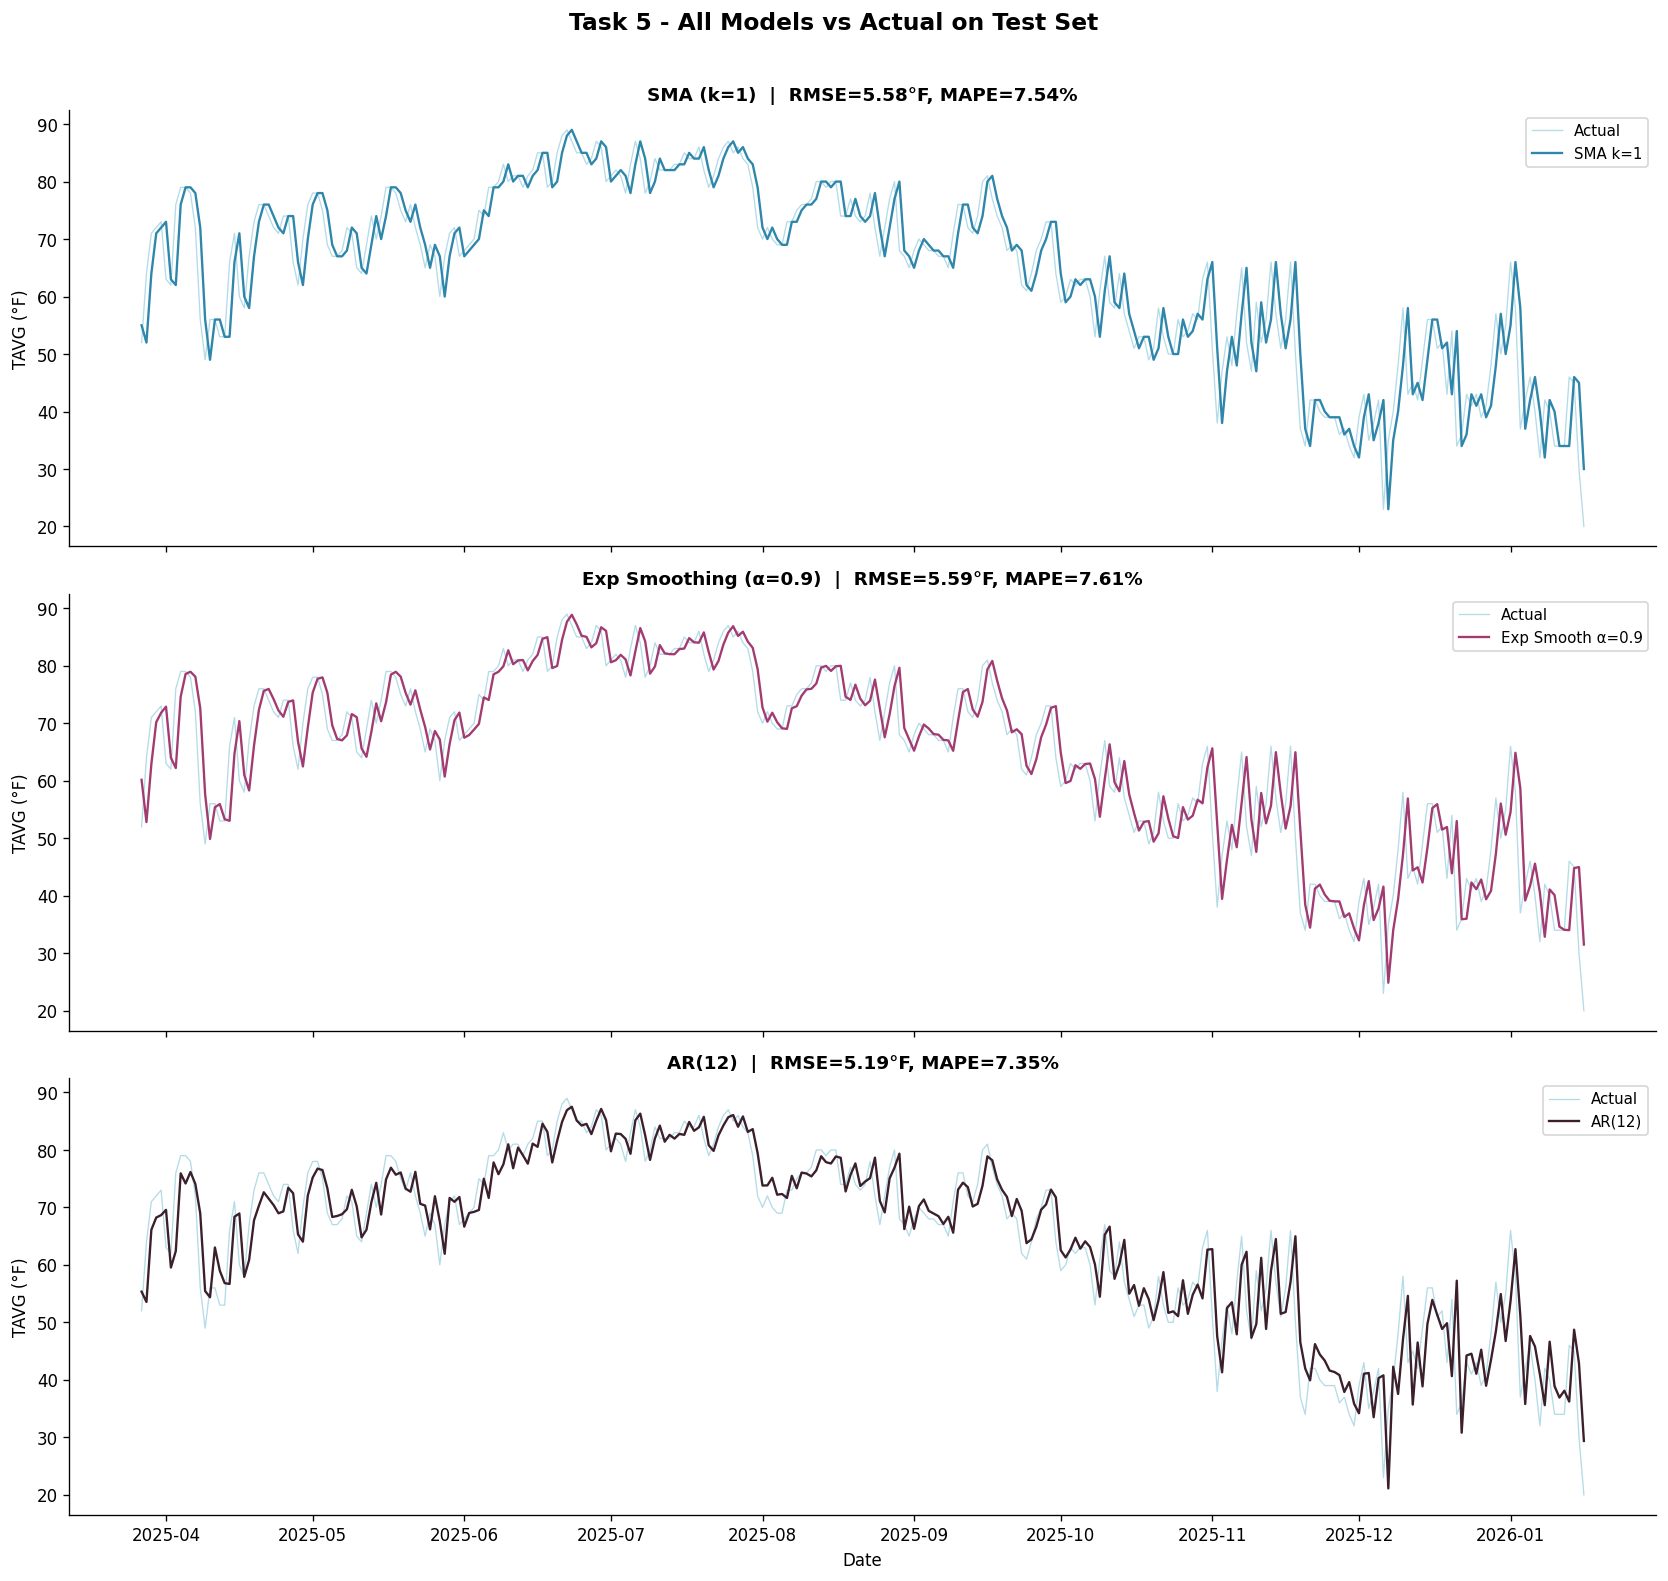

In [ ]:
# Regression models (Project 3 - Refrence) capture relationships between variables (X -> Y)
# Forecasting models (this project) capture temporal dependency (past Y -> future Y)
# All three models below are evaluated using the same rolling one-step-ahead setup
# Since TAVG is highly autocorrelated (lag-1 autocorrelation ≈ 0.93), AR modeling is appropriate

fig, axes = plt.subplots(3, 1, figsize=(14, 13), sharex=True)
test_idx = ts_test.index

axes[0].plot(test_idx, test_vals, color='lightblue', linewidth=0.8, alpha=0.9, label='Actual')
axes[0].plot(test_idx, pred_sma_test, color='#2E86AB', linewidth=1.4, label=f'SMA k={best_k}')
axes[0].set_ylabel('TAVG (°F)')
axes[0].set_title(f'SMA (k={best_k})  |  RMSE={sma_test_rmse:.2f}°F, MAPE={sma_test_mape:.2f}%', fontweight='bold')
axes[0].legend(fontsize=9)

axes[1].plot(test_idx, test_vals, color='lightblue', linewidth=0.8, alpha=0.9, label='Actual')
axes[1].plot(test_idx, pred_es_test, color='#A23B72', linewidth=1.4, label=f'Exp Smooth α={best_alpha}')
axes[1].set_ylabel('TAVG (°F)')
axes[1].set_title(f'Exp Smoothing (α={best_alpha})  |  RMSE={es_test_rmse:.2f}°F, MAPE={es_test_mape:.2f}%', fontweight='bold')
axes[1].legend(fontsize=9)

axes[2].plot(test_idx, actual_test_ar, color='lightblue', linewidth=0.8, alpha=0.9, label='Actual')
axes[2].plot(test_idx, pred_ar_test, color='#3B1F2B', linewidth=1.4, label=f'AR({p_selected})')
axes[2].set_ylabel('TAVG (°F)')
axes[2].set_xlabel('Date')
axes[2].set_title(f'AR({p_selected})  |  RMSE={ar_test_rmse:.2f}°F, MAPE={ar_test_mape:.2f}%', fontweight='bold')
axes[2].legend(fontsize=9)

fig.suptitle('Task 5 - All Models vs Actual on Test Set', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('t5_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Analysis

All three forecasting models were first derived using the training set and then evaluated on the final 20% test set using the same rolling one-step-ahead forecasting setup. This makes the comparison fair because each model predicts the next value using only past observed data and then updates after the actual value becomes available.

**Simple Moving Average (SMA):** This model predicts temperature using the average of the most recent k observations. It is easy to interpret and provides a stable baseline, but because it gives equal weight to all points in the window, it tends to lag behind rapid transitions in temperature.

**Exponential Smoothing (ES):** This model assigns higher weight to recent observations and lower weight to older ones. It reacts faster than SMA to local changes in the series and is often a stronger short-term forecasting baseline for highly autocorrelated data such as daily temperature.

**AR(p) Model:** This model is the most statistically structured of the three. It uses PACF to select the lag order and models the differenced stationary series, then converts predictions back to the original temperature scale. Because daily temperature has strong temporal dependence, AR forecasting is theoretically well motivated.

**Best model:** The best model is selected empirically based on the lowest test RMSE and MAPE under a consistent rolling forecasting setup.
Although AR models are theoretically suitable due to strong temporal autocorrelation in temperature data, actual performance depends on how well each model captures short-term dynamics in the test set.

From an IoT perspective, the results show how well future temperature can be predicted using only past sensor readings. This is useful for deciding how much historical data an edge device should retain and which forecasting method gives the best balance of simplicity and predictive accuracy.
